# Channel Flow Past Obstacles — Steady Navier-Stokes

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/camlab-ethz/TensorMesh/blob/main/notebooks/flow_obstacles.ipynb)

Steady incompressible flow through a channel with six circular obstacles at
$Re = 150$, discretized with the **Taylor-Hood P2-P1 pair** and linearized by
**Picard iteration**. The gmsh mesh is linear (order 1); the quadratic
velocity space is generated *topologically* on top of it by
`MixedElementAssembler` (one extra DOF per unique edge), so no re-meshing at
order 2 is needed. The pair is LBB-stable — no SUPG/PSPG stabilization, no
$\tau$ tuning — and the do-nothing outlet fixes the pressure gauge.

⏱️ *The default resolution takes a few minutes on Colab's free CPU runtime;
lower `N_GRID` below for a quicker run.*

Docs: [docs.tensor-mesh.com](https://docs.tensor-mesh.com) · Source: [github.com/camlab-ethz/TensorMesh](https://github.com/camlab-ethz/TensorMesh)

In [1]:
# Install TensorMesh (skipped automatically if it is already available, e.g. a local dev setup).
# The apt line provides the OpenGL utility library that gmsh -- TensorMesh's mesh generator --
# needs at import time; it is a no-op where the library is already present.
import importlib.util
if importlib.util.find_spec("tensormesh") is None:
    !apt-get -qq install -y libglu1-mesa > /dev/null 2>&1 || true
    %pip install -q tensormesh-fem==0.2.0

## Weak form

$$\rho\,(w\cdot\nabla)u\cdot v + \mu\,\nabla u : \nabla v - p\,\nabla\cdot v - q\,\nabla\cdot u$$

with $w$ the velocity from the previous Picard iterate, fed to `forward`
through `field_data` at assembly time.

In [2]:
import torch

from tensormesh import Condenser, Field, MeshGen, MixedElementAssembler


class NavierStokesAssembler(MixedElementAssembler):
    r"""Picard-linearized steady Navier-Stokes:

    .. math::

        \rho\,(w\cdot\nabla)u\cdot v + \mu\,\nabla u : \nabla v
        - p\,\nabla\cdot v - q\,\nabla\cdot u,

    with ``w`` the previous velocity iterate on the P2 field's own DOFs,
    passed via ``field_data``.
    """

    fields = [
        Field(trial="u", test="v", order=2, components=2),
        Field(trial="p", test="q", order=1),
    ]

    def __post_init__(self, rho=1.0, mu=0.01):
        self.rho = rho
        self.mu = mu

    def forward(self, gradu, p, v, gradv, q, w):
        convection = self.rho * (gradu @ w).dot(v)
        diffusion = self.mu * (gradu * gradv).sum()
        return convection + diffusion \
            - p * gradv.diagonal().sum() \
            - q * gradu.diagonal().sum()

## Geometry and mesh

`MeshGen` builds the channel with boolean cuts: a rectangle minus six disks.

In [3]:
RE = 150       # Reynolds number
N_GRID = 40    # mesh resolution; lower to 24-32 for a quicker run

OBSTACLES = [
    (0.5, 0.5, 0.10),
    (1.0, 0.3, 0.08),
    (1.0, 0.7, 0.08),
    (1.5, 0.5, 0.12),
    (2.0, 0.4, 0.07),
    (2.0, 0.6, 0.07),
]
LENGTH, HEIGHT = 3.0, 1.0

gen = MeshGen(chara_length=1.0 / N_GRID)
gen.add_rectangle(0.0, 0.0, LENGTH, HEIGHT)
for ox, oy, orad in OBSTACLES:
    gen.remove_circle(ox, oy, orad)
mesh = gen.gen().double()

assembler = NavierStokesAssembler.from_mesh(mesh, rho=1.0, mu=1.0 / RE)
layout = assembler.layout
print(f"mesh: {mesh.points.shape[0]} P1 points, "
      f"{layout.n_nodes('u')} P2 velocity nodes, {layout.n_dofs} DOFs")


mesh: 5788 P1 points, 22712 P2 velocity nodes, 51212 DOFs


In [4]:
# Boundary conditions on the P2 velocity space: parabolic inlet on the left,
# do-nothing outlet on the right (fixes the pressure gauge), no-slip elsewhere.
x_u = layout.points("u")
is_boundary = layout.split(layout.boundary_mask("u"))["u"][:, 0]  # node level
eps = 1e-6
is_inlet = is_boundary & (x_u[:, 0] < eps)
is_outlet = x_u[:, 0] > LENGTH - eps
no_slip = is_boundary & ~is_inlet & ~is_outlet  # channel walls + obstacles

bc_mask = layout.dof_mask("u", node_mask=is_inlet | no_slip)
bc_val = torch.zeros(layout.n_dofs, dtype=torch.float64)
y_in = x_u[is_inlet, 1]
bc_val[layout.dof_mask("u", node_mask=is_inlet, component=0)] = \
    4.0 * y_in * (HEIGHT - y_in) / (HEIGHT * HEIGHT)  # parabolic inlet

condenser = Condenser(bc_mask, bc_val[bc_mask])

## Picard iteration

Each iteration reassembles the convection term around the previous velocity
and solves the linearized saddle-point system; the same `Condenser` is
reused across all iterations.

In [5]:
max_iter, tol = 30, 5e-4

sol = torch.zeros(layout.n_dofs, dtype=torch.float64)
sol[bc_mask] = bc_val[bc_mask]

for i in range(max_iter):
    w = layout.split(sol)["u"]  # previous-iterate velocity on the P2 DOFs
    K = assembler(field_data={"w": ("u", w)})
    f = torch.zeros(layout.n_dofs, dtype=torch.float64)

    K_, f_ = condenser(K, f)
    sol_new = condenser.recover(K_.solve(f_))

    diff = torch.norm(sol_new - sol) / (torch.norm(sol_new) + 1e-8)
    print(f"Picard {i:2d}: relative diff = {diff:.6e}")
    sol = sol_new
    if diff < tol:
        print("Converged!")
        break

Picard  0: relative diff = 9.986921e-01


Picard  1: relative diff = 2.892396e-01


Picard  2: relative diff = 9.995774e-02


Picard  3: relative diff = 3.122927e-02


Picard  4: relative diff = 1.036436e-02


Picard  5: relative diff = 2.852376e-03


Picard  6: relative diff = 7.769615e-04


Picard  7: relative diff = 2.026400e-04
Converged!


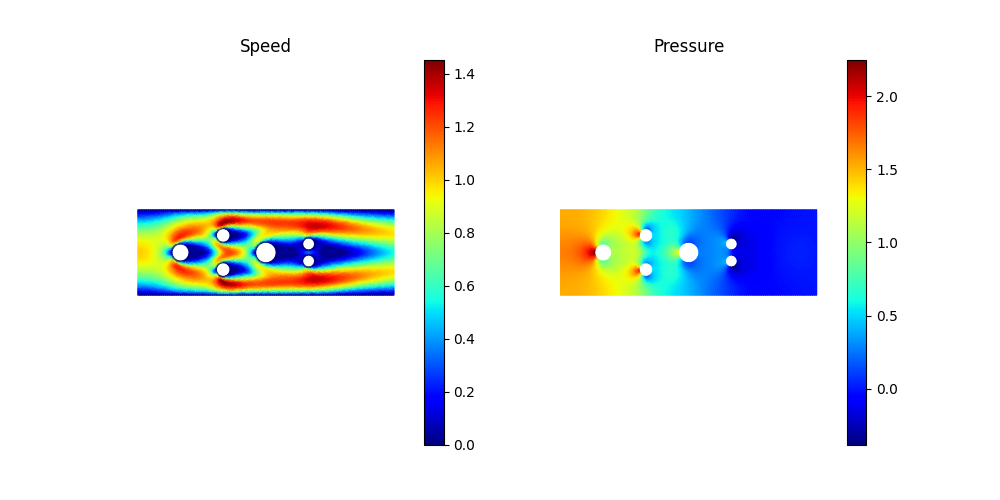

In [6]:
fields = layout.split(sol)
speed = layout.prolong("u", fields["u"]).norm(dim=1)  # on mesh points
pressure = fields["p"]  # P1 == mesh points

mesh.plot(
    {"Speed": speed, "Pressure": pressure},
    save_path="flow_obstacles.png", show_mesh=False, cmap="jet",
)
import matplotlib.pyplot as plt
plt.close("all")  # mesh.plot leaves its figure open; avoid a duplicate inline render
from IPython.display import Image
Image("flow_obstacles.png")